In [2]:
%autosave 60
from IPython.display import display, HTML
import s3fit
display(HTML("<style>.container { width:100% !important; }</style>"))
import os
os.environ["OPENBLAS_NUM_THREADS"] = "64"

from copy import deepcopy as copy
import matplotlib.pyplot as plt

import warnings

import astropy.units as u
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
import numpy as np
import pandas as pd
import os
import pathlib
import matplotlib as mpl
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from collections import defaultdict
import re
import scipy
from astropy.io import fits as asfits
from s3fit import FitFrame

mpl.rcParams['font.family'] = 'serif'


import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    './DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()

s3fit_results_path = pathlib.Path('./s3fit_results/')
s3fit_results_path.mkdir(parents=True, exist_ok=True)

figs_path=pathlib.Path('./figs_spectrum_fits/')
figs_path.mkdir(parents=True, exist_ok=True)

Autosaving every 60 seconds


537


In [4]:
len(os.listdir(s3fit_results_path))

170

In [2]:
ssp_config = {'main': {'pars': [[-1000, 1000, 'free'], [100, 1200, 'free'], [0, 5.0, 'free'],
                        [0, 0.94, 'free'], [-1, 1, 'free']],
                'info': {'age_min': -2.25, 'age_max': 'universe', 'met_sel': 'solar', 'sfh_name': 'exponential'} },
        'young': {'pars': [[None, None, 'ssp:main:0'], [None, None, 'ssp:main:1'], [None, None, 'ssp:main:2'],
                            [-2, -1, 'free'], [-1, -1, 'fix']],
                'info': {'age_min': -2.25, 'age_max': 0, 'met_sel': 'solar', 'sfh_name': 'constant'} } }

ssp_file = './models/popstar_for_s3fit.fits'

el_config = {'NLR': {'pars':       [[ -500,   500, 'free'], [1,  750, 'free'], [0, 5, 'free'], [1.3, 4.3, 'free'], [4, None, 'fix']],
                    'info': {'line_used': ['all']}},
             'outflow_1': {'pars': [[-2000,   100, 'free'], [750, 2500, 'free'], [0, 5, 'free'], [1.3, 4.3, 'free'], [4, None, 'fix']],
                           'info': {'line_used': ['all']}},
             }


model_config = {'ssp': {'enable': True, 'config': ssp_config, 'file': ssp_file},
                'el': {'enable': True, 'config': el_config, 'use_pyneb': True}}


In [3]:

def plot_spectrum_and_save(survey_id_subid, disperser_filter, converted_flux, converted_flux_error, converted_wave, redshift, save_path=figs_path):
    fig, ax=plt.subplots(figsize=(20,8))
    ax.plot(converted_wave.value, converted_flux.value, color='blue', lw=1, label='Observed Spectrum')
    ax.fill_between(converted_wave.value, converted_flux.value - 3*converted_flux_error.value,
                    converted_flux.value + 3*converted_flux_error.value, color='gray', alpha=0.5, label='3$\sigma$ Error Region')
    oiii_mask = (converted_wave.value > 4960*(1+redshift)) & (converted_wave.value < 5030*(1+redshift))
    halpha_mask = (converted_wave.value > 6550*(1+redshift)) & (converted_wave.value < 6570*(1+redshift))
    y_range_threshold = np.nanmax(converted_flux.value[halpha_mask])*1.2
    ax.set_ylim(-0.5*y_range_threshold, 1.0*y_range_threshold)
    ax.set_xlim(4501*(1+redshift), 6750*(1+redshift))



    ax.minorticks_on()
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')


    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('bottom')
    ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=14)
    ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=14)
    ax.xaxis.set_tick_params(length=6, which='major')
    ax.xaxis.set_tick_params(length=3, which='minor')
    ax.yaxis.set_tick_params(length=6, which='major')
    ax.yaxis.set_tick_params(length=3, which='minor')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
    ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=1)
    ax.grid(visible=True, which='minor', color='lightgray', linestyle='--', linewidth=0.5)
    ax.set_xlabel('Observed Wavelength (Å)', fontsize=16)
    ax.set_ylabel(r'$F_\lambda$ ($\rm{erg\ s^{-1}\ cm^{-2}\ \AA^{-1}}$)', fontsize=16)
    #add another x axis on the top to show rest-frame wavelength
    ax_top = ax.secondary_xaxis('top', functions=(lambda x: x / (1 + redshift), lambda x: x * (1 + redshift)))
    ax_top.minorticks_on()
    ax_top.set_xlabel('Rest-frame Wavelength (Å)', fontsize=16)
    ax_top.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=14)
    ax_top.xaxis.set_tick_params(length=6, which='major')
    ax_top.xaxis.set_tick_params(length=3, which='minor')
    fig.suptitle(f'Spectrum for {survey_id_subid} - {disperser_filter}', fontsize=20)
    plt.savefig(save_path/(f'spectrum_{survey_id_subid}_{disperser_filter}.pdf'), bbox_inches='tight')
    plt.close(fig)

    return



In [7]:
for survey_id_subid, catalog in DJAv4Catalog.catalog_iterator(20):
    if not catalog['sample_flag']:
        continue

    for disperser_filter, _ in catalog['lines_fit'].items():
        grating_filepath=catalog['grating_filepaths'][disperser_filter]

        redshift=catalog['determined_redshift']

        disperser_name, filter_name = disperser_filter.split('-')

        with asfits.open(grating_filepath) as grating_spectrum_fits:

            observed_wave=grating_spectrum_fits[1].data['wave']*u.micron
            observed_flux=grating_spectrum_fits[1].data['flux']*u.mJy
            observed_flux_error=grating_spectrum_fits[1].data['err']*u.mJy

            non_nan_mask = np.isfinite(observed_flux.value) & np.isfinite(observed_flux_error.value)


            target_flux_lambda_unit = u.erg / u.s / u.cm**2 / u.AA

            converted_flux = observed_flux.to(target_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))
            converted_flux_error = observed_flux_error.to(target_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))

            converted_wave = observed_wave.to(u.AA)


            error_threshold = 10*np.nanmedian(converted_flux_error.value) * u.erg / u.s / u.cm**2 / u.AA
            non_nan_mask &= (converted_flux_error < error_threshold)


            spec_valid_range = []
            if non_nan_mask.any():
                mask_int = non_nan_mask.astype(int)
                padded_mask = np.concatenate(([0], mask_int, [0]))
                diff = np.diff(padded_mask)

                starts_indices = np.where(diff == 1)[0]
                ends_indices = np.where(diff == -1)[0] - 1

                for start_idx, end_idx in zip(starts_indices, ends_indices):
                    start_wave = converted_wave[start_idx].value
                    end_wave = converted_wave[end_idx].value
                    spec_valid_range.append([start_wave, end_wave])

            resolution_fits=asfits.open(pathlib.Path('~/jwst_disperser_resolution').expanduser()/('jwst_nirspec_'+disperser_name+'_disp.fits'))
            R_array=resolution_fits[1].data['R']
            R_wave=(resolution_fits[1].data['WAVELENGTH']*u.micron).to(u.AA).value

            k,b=np.polyfit(R_wave, R_array, 1)

            spec_R_array=k*converted_wave.value+b

            plot_spectrum_and_save(survey_id_subid, disperser_filter, converted_flux, converted_flux_error, converted_wave, redshift, save_path=figs_path)


            FF_biSFH=FitFrame(spec_wave_w=converted_wave.value[non_nan_mask], spec_flux_w=converted_flux.value[non_nan_mask], spec_ferr_w=converted_flux_error.value[non_nan_mask], spec_R_inst_w=spec_R_array[non_nan_mask], spec_valid_range=None, v0_redshift=redshift, model_config=model_config, num_mocks=0, print_step=False,plot_step=False,examine_result=False)
            FF_biSFH.main_fit()
            FF_biSFH.save_to_file(pathlib.Path.joinpath(s3fit_results_path, f's3fit_{survey_id_subid}_{disperser_filter}.pkl.gz'))



################################# S3Fit starts #################################
You are now using S3Fit v2.2.5.
############################# Initialize FitFrame ##############################
Perform fitting for the original data and 0 mock data.
[Note] The examination of S/N of models and the updating of fitting will be skipped since examine_result=False.
Perform fitting in linear space.
############################## Read spectral data ##############################
Spectral fitting will be performed in wavelength range (rest frame, AA): from 3820.015 to 9924.618
[Note] The wavelength range is extended for a tolerance of redshift of 3.1096000000000004+-0.0033 (+-1000 km/s).
##################### Initialize stellar continuum models ######################
Resample SSP models with bin width of 0.529 AA in a resolution of 1.057 AA
[WARNING]: Upper bound of CSP_Age of the component 'main'  is reset to the universe age 2.093 Gyr at z = 3.1096000000000004.
SSP models normalization wavelen

KeyboardInterrupt: 

In [33]:
survey_id_subid='jades-gdn2-v4_1181_40013'
catalog=DJAv4Catalog.catalog[survey_id_subid]

for disperser_filter, _ in catalog['lines_fit'].items():
    grating_filepath=catalog['grating_filepaths'][disperser_filter]

    redshift=catalog['determined_redshift']

    disperser_name, filter_name = disperser_filter.split('-')

    with asfits.open(grating_filepath) as grating_spectrum_fits:

        observed_wave=grating_spectrum_fits[1].data['wave']*u.micron
        observed_flux=grating_spectrum_fits[1].data['flux']*u.mJy
        observed_flux_error=grating_spectrum_fits[1].data['err']*u.mJy

        non_nan_mask = np.isfinite(observed_flux.value) & np.isfinite(observed_flux_error.value)


        target_flux_lambda_unit = u.erg / u.s / u.cm**2 / u.AA

        converted_flux = observed_flux.to(target_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))
        converted_flux_error = observed_flux_error.to(target_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))

        converted_wave = observed_wave.to(u.AA)


        error_threshold = 10*np.nanmedian(converted_flux_error.value) * u.erg / u.s / u.cm**2 / u.AA
        non_nan_mask &= (converted_flux_error < error_threshold)


        snr_threshold=np.nanpercentile(np.abs(converted_flux.value) / converted_flux_error.value,10)
        non_nan_mask &= (np.abs(converted_flux.value) / converted_flux_error.value > snr_threshold)


        spec_valid_range = []
        if non_nan_mask.any():
            mask_int = non_nan_mask.astype(int)
            padded_mask = np.concatenate(([0], mask_int, [0]))
            diff = np.diff(padded_mask)

            starts_indices = np.where(diff == 1)[0]
            ends_indices = np.where(diff == -1)[0] - 1

            for start_idx, end_idx in zip(starts_indices, ends_indices):
                start_wave = converted_wave[start_idx].value
                end_wave = converted_wave[end_idx].value
                spec_valid_range.append([start_wave, end_wave])

        resolution_fits=asfits.open(pathlib.Path('~/jwst_disperser_resolution').expanduser()/('jwst_nirspec_'+disperser_name+'_disp.fits'))
        R_array=resolution_fits[1].data['R']
        R_wave=(resolution_fits[1].data['WAVELENGTH']*u.micron).to(u.AA).value

        k,b=np.polyfit(R_wave, R_array, 1)

        spec_R_array=k*converted_wave.value+b

        plot_spectrum_and_save(survey_id_subid, disperser_filter, converted_flux, converted_flux_error, converted_wave, redshift, save_path=figs_path)


        FF_biSFH=FitFrame(spec_wave_w=converted_wave.value[non_nan_mask], spec_flux_w=converted_flux.value[non_nan_mask], spec_ferr_w=converted_flux_error.value[non_nan_mask], spec_R_inst_w=spec_R_array[non_nan_mask], spec_valid_range=spec_valid_range, v0_redshift=redshift, model_config=model_config, num_mocks=0, print_step=False,plot_step=True,examine_result=True)
        FF_biSFH.main_fit()

################################# S3Fit starts #################################
You are now using S3Fit v2.2.5.
############################# Initialize FitFrame ##############################
Perform fitting for the original data and 0 mock data.
Perform fitting in linear space.
############################## Read spectral data ##############################
Mask out 0 data points with the input spec_valid_range.
Spectral fitting will be performed in wavelength range (rest frame, AA): from 3363.423 to 9462.439
[Note] The wavelength range is extended for a tolerance of redshift of 3.6630000000000003+-0.0033 (+-1000 km/s).
##################### Initialize stellar continuum models ######################
Resample SSP models with bin width of 0.482 AA in a resolution of 0.963 AA
[WARNING]: Upper bound of CSP_Age of the component 'main'  is reset to the universe age 1.734 Gyr at z = 3.6630000000000003.
SSP models normalization wavelength: 5500 +- 25
SSP models number: 61 used in a total of

Traceback (most recent call last):
  File "/home/xingyaocai/DustCurve/s3fit/fit_frame.py", line 830, in nonlinear_process
    da_solution = dual_annealing(lambda x, *args: 0.5*np.sum(self.linear_process(x, *args)**2),
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/scipy/_lib/_util.py", line 440, in wrapper
    return fun(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^
  File "/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/scipy/optimize/_dual_annealing.py", line 674, in dual_annealing
    energy_state.reset(func_wrapper, rng_gen, x0)
  File "/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/scipy/optimize/_dual_annealing.py", line 173, in reset
    self.current_energy = func_wrapper.fun(self.current_location)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/xingyaocai/miniconda3/en

SystemExit: 

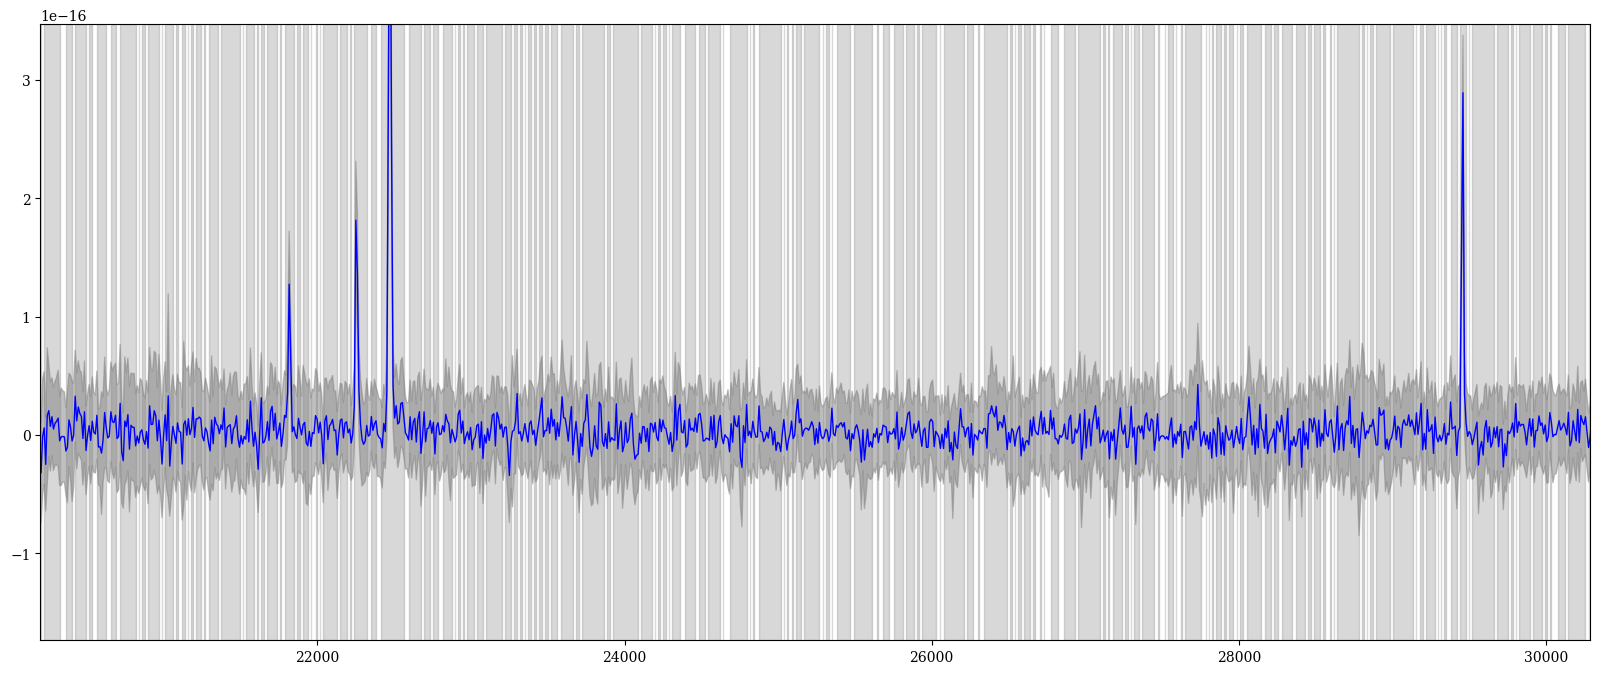

In [175]:
non_nan_mask = np.isfinite(observed_flux.value) & np.isfinite(observed_flux_error.value)


target_flux_lambda_unit = u.erg / u.s / u.cm**2 / u.AA

converted_flux = observed_flux.to(target_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))
converted_flux_error = observed_flux_error.to(target_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))

converted_wave = observed_wave.to(u.AA)


error_threshold = 10*np.nanmedian(converted_flux_error.value) * u.erg / u.s / u.cm**2 / u.AA
non_nan_mask &= (converted_flux_error < error_threshold)

snr_threshold=np.nanpercentile(np.abs(converted_flux.value) / converted_flux_error.value,20)
non_nan_mask &= (np.abs(converted_flux.value) / converted_flux_error.value > snr_threshold)


spec_valid_range = []
if non_nan_mask.any():
    mask_int = non_nan_mask.astype(int)
    padded_mask = np.concatenate(([0], mask_int, [0]))
    diff = np.diff(padded_mask)

    starts_indices = np.where(diff == 1)[0]
    ends_indices = np.where(diff == -1)[0] - 1

    for start_idx, end_idx in zip(starts_indices, ends_indices):
        start_wave = converted_wave[start_idx].value
        end_wave = converted_wave[end_idx].value
        spec_valid_range.append([start_wave, end_wave])

fig, ax=plt.subplots(figsize=(20,8))
ax.plot(converted_wave.value, converted_flux.value, color='blue', lw=1, label='Observed Spectrum')
ax.fill_between(converted_wave.value, converted_flux.value - 3*converted_flux_error.value,
                converted_flux.value + 3*converted_flux_error.value, color='gray', alpha=0.5, label='3$\sigma$ Error Region')
oiii_mask = (converted_wave.value > 4960*(1+redshift)) & (converted_wave.value < 5030*(1+redshift))
halpha_mask = (converted_wave.value > 6550*(1+redshift)) & (converted_wave.value < 6570*(1+redshift))
y_range_threshold = np.nanmax(converted_flux.value[halpha_mask])*1.2
ax.set_ylim(-0.5*y_range_threshold, 1.0*y_range_threshold)
ax.set_xlim(4501*(1+redshift), 6750*(1+redshift))
for start_wave, end_wave in spec_valid_range:
    plt.axvspan(start_wave, end_wave, color='gray', alpha=0.3)

In [177]:
np.nanmedian(np.abs(converted_flux.value / converted_flux_error.value)) / np.nanpercentile(np.abs(converted_flux.value / converted_flux_error.value), 5)

np.float64(10.034938263964515)

In [179]:
np.nanmean(np.abs(converted_flux.value) / converted_flux_error.value) / np.nanpercentile(np.abs(converted_flux.value / converted_flux_error.value), 5)

np.float64(12.724939188024308)

In [183]:
np.nanpercentile(np.abs(converted_flux.value / converted_flux_error.value), 10)

np.float64(0.11101130801589136)

(array([104., 111.,  98., 106., 101.,  85.,  80., 108., 114.,  85.,  90.,
         90.,  70.,  80.,  84.,  78.,  59.,  78.,  55.,  57.,  62.,  50.,
         45.,  43.,  46.,  42.,  29.,  22.,  22.,  33.,  22.,  26.,  25.,
         18.,  17.,  13.,   9.,  15.,   6.,   3.,   8.,  13.,   6.,   7.,
          8.,  10.,   1.,   2.,   2.,   3.,   4.,   2.,   1.,   2.,   2.,
          1.,   2.,   0.,   0.,   1.,   2.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
        1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ,
        1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15,
        2.2 , 2.25, 2.

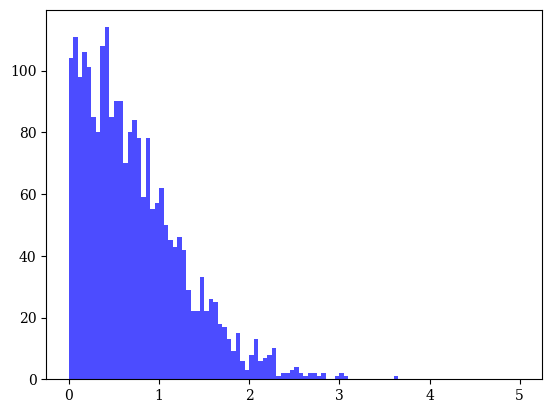

In [185]:
plt.hist(np.abs(converted_flux.value) / converted_flux_error.value, bins=100, range=(0,5), color='blue', alpha=0.7)

In [3]:

median=np.array([])
mean=np.array([])
percentile_10=np.array([])
percentile_5=np.array([])

for survey_id_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    for disperser_filter, _ in catalog['lines_fit'].items():
        grating_filepath=catalog['grating_filepaths'][disperser_filter]

        redshift=catalog['determined_redshift']

        disperser_name, filter_name = disperser_filter.split('-')

        with asfits.open(grating_filepath) as grating_spectrum_fits:

            observed_wave=grating_spectrum_fits[1].data['wave']*u.micron
            observed_flux=grating_spectrum_fits[1].data['flux']*u.mJy
            observed_flux_error=grating_spectrum_fits[1].data['err']*u.mJy

            non_nan_mask = np.isfinite(observed_flux.value) & np.isfinite(observed_flux_error.value)


            target_flux_lambda_unit = u.erg / u.s / u.cm**2 / u.AA

            converted_flux = observed_flux.to(target_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))
            converted_flux_error = observed_flux_error.to(target_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))

            converted_wave = observed_wave.to(u.AA)


            error_threshold = 10*np.nanmedian(converted_flux_error.value) * u.erg / u.s / u.cm**2 / u.AA
            non_nan_mask &= (converted_flux_error < error_threshold)

            snr_threshold=np.nanpercentile(np.abs(converted_flux.value) / converted_flux_error.value,20)
            non_nan_mask &= (np.abs(converted_flux.value) / converted_flux_error.value > snr_threshold)

            median=np.append(median, np.nanmedian(np.abs(converted_flux.value/converted_flux_error.value)))
            mean=np.append(mean, np.nanmean(np.abs(converted_flux.value/converted_flux_error.value)))
            percentile_10=np.append(percentile_10, np.nanpercentile(np.abs(converted_flux.value/converted_flux_error.value),10))
            percentile_5=np.append(percentile_5, np.nanpercentile(np.abs(converted_flux.value/converted_flux_error.value),5))




(0.0, 6.0)

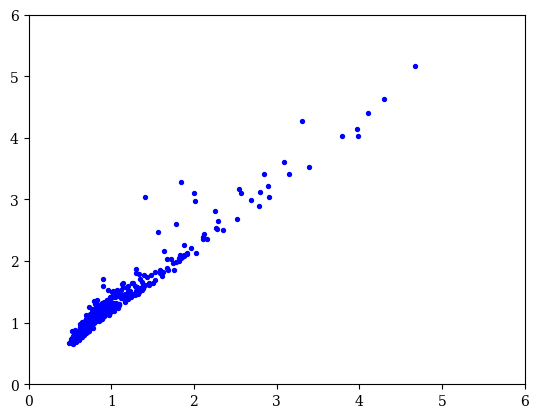

In [3]:
plt.scatter(np.abs(median), np.abs(mean),s=8,c='blue',alpha=1)
plt.ylim(0,6)
plt.xlim(0,6)

(array([  0.,   0.,   0.,   0.,   1., 116., 321., 166.,  81.,  44.,  38.,
         29.,  10.,  17.,   9.,  11.,   8.,   5.,  11.,   5.,   3.,   4.,
          5.,   1.,   0.,   3.,   1.,   2.,   3.,   1.,   1.,   1.,   1.,
          2.,   0.,   0.,   0.,   1.,   0.,   2.,   0.,   1.,   1.,   1.,
          0.,   0.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
         1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
         2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
         3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
         4.4,  4.5,  4

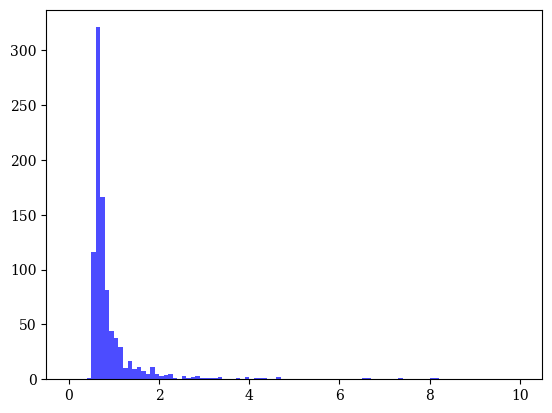

In [191]:
plt.hist(np.abs(median), bins=100, range=(0,10), color='blue', alpha=0.7)

In [4]:

fig, ax=plt.subplots(figsize=(24,14))

ax.hist(median, bins=100, alpha=0.7, label='Median SNR',range=(0,1.5))
ax.hist(percentile_10, bins=100, alpha=0.7, label='10th Percentile SNR',range=(0,1.5))
ax.hist(mean, bins=100, alpha=0.7, label='Mean SNR',range=(0,1.5))
ax.hist(percentile_5, bins=100, alpha=0.7, label='5th Percentile SNR',range=(0,1.5))

ax.legend(fontsize=24, loc='upper right')
ax.set_xlabel('SNR', fontsize=24)
ax.set_ylabel('Number of Spectra', fontsize=24)


ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('bottom')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
fig.suptitle('Statistics of Spectrum Pixel SNRs', fontsize=28)
ax.set_ylim(0, 225)
plt.tight_layout()


inset_ax = ax.inset_axes([0.25, 0.35, 0.7, 0.55])

# 在内嵌图上重新绘制直方图，但不设置 ylim
inset_ax.hist(median, bins=100, alpha=0.7, label='Median SNR', range=(0,1.5))
inset_ax.hist(percentile_10, bins=100, alpha=0.7, label='10th Percentile SNR', range=(0,1.5))
inset_ax.hist(mean, bins=100, alpha=0.7, label='Mean SNR', range=(0,1.5))
inset_ax.hist(percentile_5, bins=100, alpha=0.7, label='5th Percentile SNR', range=(0,1.5))
inset_ax.set_ylim(0, 35)
inset_ax.set_xlim(0,1.4)

# 设置内嵌图的标签和刻度等（通常简化以避免拥挤）
inset_ax.set_title('Zoom-In Distribution', fontsize=18)
inset_ax.tick_params(labelsize=8) # 减小内嵌图刻度标签的大小
inset_ax.set_xlabel('SNR', fontsize=14)
inset_ax.set_ylabel('Count', fontsize=14)
inset_ax.spines['bottom'].set_linewidth(1)
inset_ax.spines['top'].set_linewidth(1)
inset_ax.spines['left'].set_linewidth(1)
inset_ax.spines['right'].set_linewidth(1)
inset_ax.spines['bottom'].set_color('black')
inset_ax.spines['top'].set_color('black')
inset_ax.spines['left'].set_color('black')
inset_ax.spines['right'].set_color('black')
inset_ax.yaxis.set_ticks_position('both')
inset_ax.xaxis.set_ticks_position('bottom')
inset_ax.xaxis.set_tick_params(width=1, direction='in', which='both', labelsize=10)
inset_ax.yaxis.set_tick_params(width=1, direction='in', which='both', labelsize=10)
inset_ax.xaxis.set_tick_params(length=4, which='major')
inset_ax.xaxis.set_tick_params(length=2, which='minor')
inset_ax.yaxis.set_tick_params(length=4, which='major')
inset_ax.yaxis.set_tick_params(length=2, which='minor')

# 可选：绘制连接线，使内嵌图更清晰地指示它所放大的区域
ax.indicate_inset_zoom(inset_ax, edgecolor="black", linewidth=2, facecolor='gray', alpha=0.2)

z_value = 10

ax.plot([0, 0.337], [0, 79], color='black', lw=1,alpha=0.6,ls='-.', zorder=z_value)
ax.plot([0, 0.337], [35, 202.5], color='black', lw=1,alpha=0.6,ls='-.', zorder=z_value)
ax.plot([1.4, 1.493], [0, 79], color='black', lw=1,alpha=0.6,ls='-.', zorder=z_value)
ax.plot([1.4, 1.493], [35, 202.5], color='black', lw=1,alpha=0.6,ls='-.', zorder=z_value)

plt.savefig('./spectrum_snr_statistics.pdf')
plt.close(fig)

(array([  5.,   2.,   5.,   2.,   3.,   9.,   4.,   6.,   7.,   6.,  10.,
         12.,   6.,  23.,  33.,  67.,  87., 115., 130., 107.,  88.,  85.,
         38.,  18.,  12.,  10.,  10.,   4.,   2.,   2.,   1.,   3.,   0.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   1.]),
 array([ 1.84954706,  2.48950854,  3.12947002,  3.7694315 ,  4.40939298,
         5.04935446,  5.68931594,  6.32927742,  6.9692389 ,  7.60920038,
         8.24916187,  8.88912335,  9.52908483, 10.16904631, 10.80900779,
        11.44896927, 12.08893075, 12.72889223, 13.36885371, 14.00881519,
        14.64877667, 15.28873816, 15.92869964, 16.56866112, 17.2086226 ,
        17.84858408, 18.48854556, 19.12850704, 19.76846852, 20.40843   ,
        21.04839148, 21.68835296, 22.32831445, 22.96827593, 23.60823741,
        24.24819889, 24.88816037, 25.52812185, 26.16808333, 26.80804481,
        27.44800629, 28.08796777, 28.72792925, 29.36789073, 30.00785222,
 

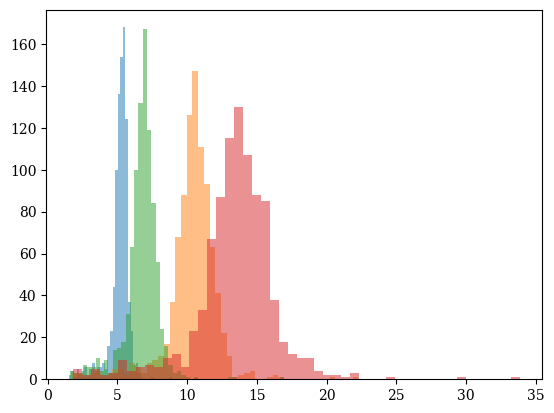

In [109]:
plt.hist(median/percentile_10, bins=50, alpha=0.5, label='Median SNR / 10th Percentile SNR')
plt.hist(median/percentile_5, bins=50, alpha=0.5, label='Median SNR / 5th Percentile SNR')
plt.hist(mean/percentile_10, bins=50, alpha=0.5, label='Mean SNR / 10th Percentile SNR')
plt.hist(mean/percentile_5, bins=50, alpha=0.5, label='Mean SNR / 5th Percentile SNR')
#check which one is the best fit with gaussian

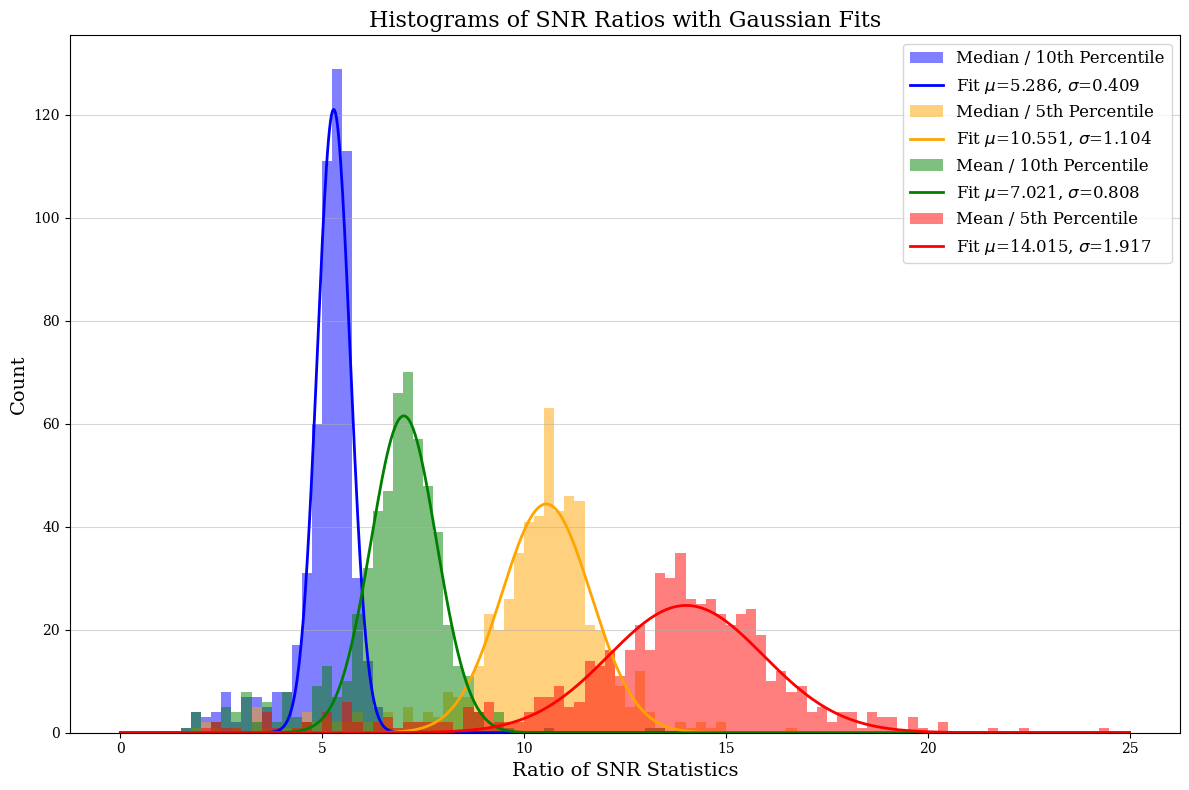

In [215]:
from scipy.optimize import curve_fit

# 1. 定义高斯函数 (没有背景/偏移 offset)
def gaussian(x, A, mu, sigma):
    """A * exp(-(x-mu)^2 / (2*sigma^2))"""
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# 2. 准备要拟合的数据列表
datasets_raw = [
    (median / percentile_10, 'Median / 10th Percentile', 'blue'),
    (median / percentile_5, 'Median / 5th Percentile', 'orange'),
    (mean / percentile_10, 'Mean / 10th Percentile', 'green'),
    (mean / percentile_5, 'Mean / 5th Percentile', 'red')
]

# 3. 设置绘图
fig, ax = plt.subplots(figsize=(12, 8))
n_bins = 100
x_range = (0,25) # 统一的X轴范围

# 存储拟合结果用于报告
fit_results = []

for data_raw, label, color in datasets_raw:
    # ====== 关键修改：筛选掉 NaN 和 Inf ======
    data = data_raw[np.isfinite(data_raw)]

    # 检查数据是否足够进行拟合
    if len(data) < 10:
        print(f"Skipping {label}: Insufficient valid data.")
        continue
    # ==========================================

    # 3a. 计算直方图的 bin 计数和 bin 边缘
    counts, bin_edges = np.histogram(data, bins=n_bins, range=x_range)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 3b. 初始参数猜测 (p0): [Amplitude, Mean, Sigma]
    p0 = [np.max(counts), np.mean(data), np.std(data)]

    # 3c. 进行高斯拟合
    try:
        # 使用 counts 的平方根作为误差，进行加权拟合
        sigma_counts = np.sqrt(counts)
        sigma_counts[sigma_counts == 0] = 1

        # 将 count == 0 的 bin 排除在外，避免卡方计算错误
        valid_bins = counts > 0
        bin_centers_fit = bin_centers[valid_bins]
        counts_fit = counts[valid_bins]
        sigma_counts_fit = sigma_counts[valid_bins]

        popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit,
                               p0=p0, sigma=sigma_counts_fit)
        A_fit, mu_fit, sigma_fit = popt

        dof = len(counts_fit) - len(popt)

        # 3e. 绘制直方图
        ax.hist(data, bins=n_bins, alpha=0.5, label=label, range=x_range, color=color)

        # 3f. 叠加拟合的高斯曲线 (使用更精细的 X 值)
        x_fit = np.linspace(x_range[0], x_range[1], 1000)
        y_fit = gaussian(x_fit, A_fit, mu_fit, sigma_fit)

        ax.plot(x_fit, y_fit, color=color, linestyle='-', linewidth=2,
                label=f'Fit $\mu$={mu_fit:.3f}, $\sigma$={sigma_fit:.3f}')

    except Exception as e:
        print(f"Error: Could not fit Gaussian to {label}. Reason: {e}")
        ax.hist(data, bins=n_bins, alpha=0.5, label=label + " (Fit Failed)", range=x_range, color=color)


# 4. 添加图表美化 (省略了与 NaN 无关的部分，以保持简洁)
ax.set_xlabel('Ratio of SNR Statistics', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_title('Histograms of SNR Ratios with Gaussian Fits', fontsize=16)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

In [116]:
counts

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

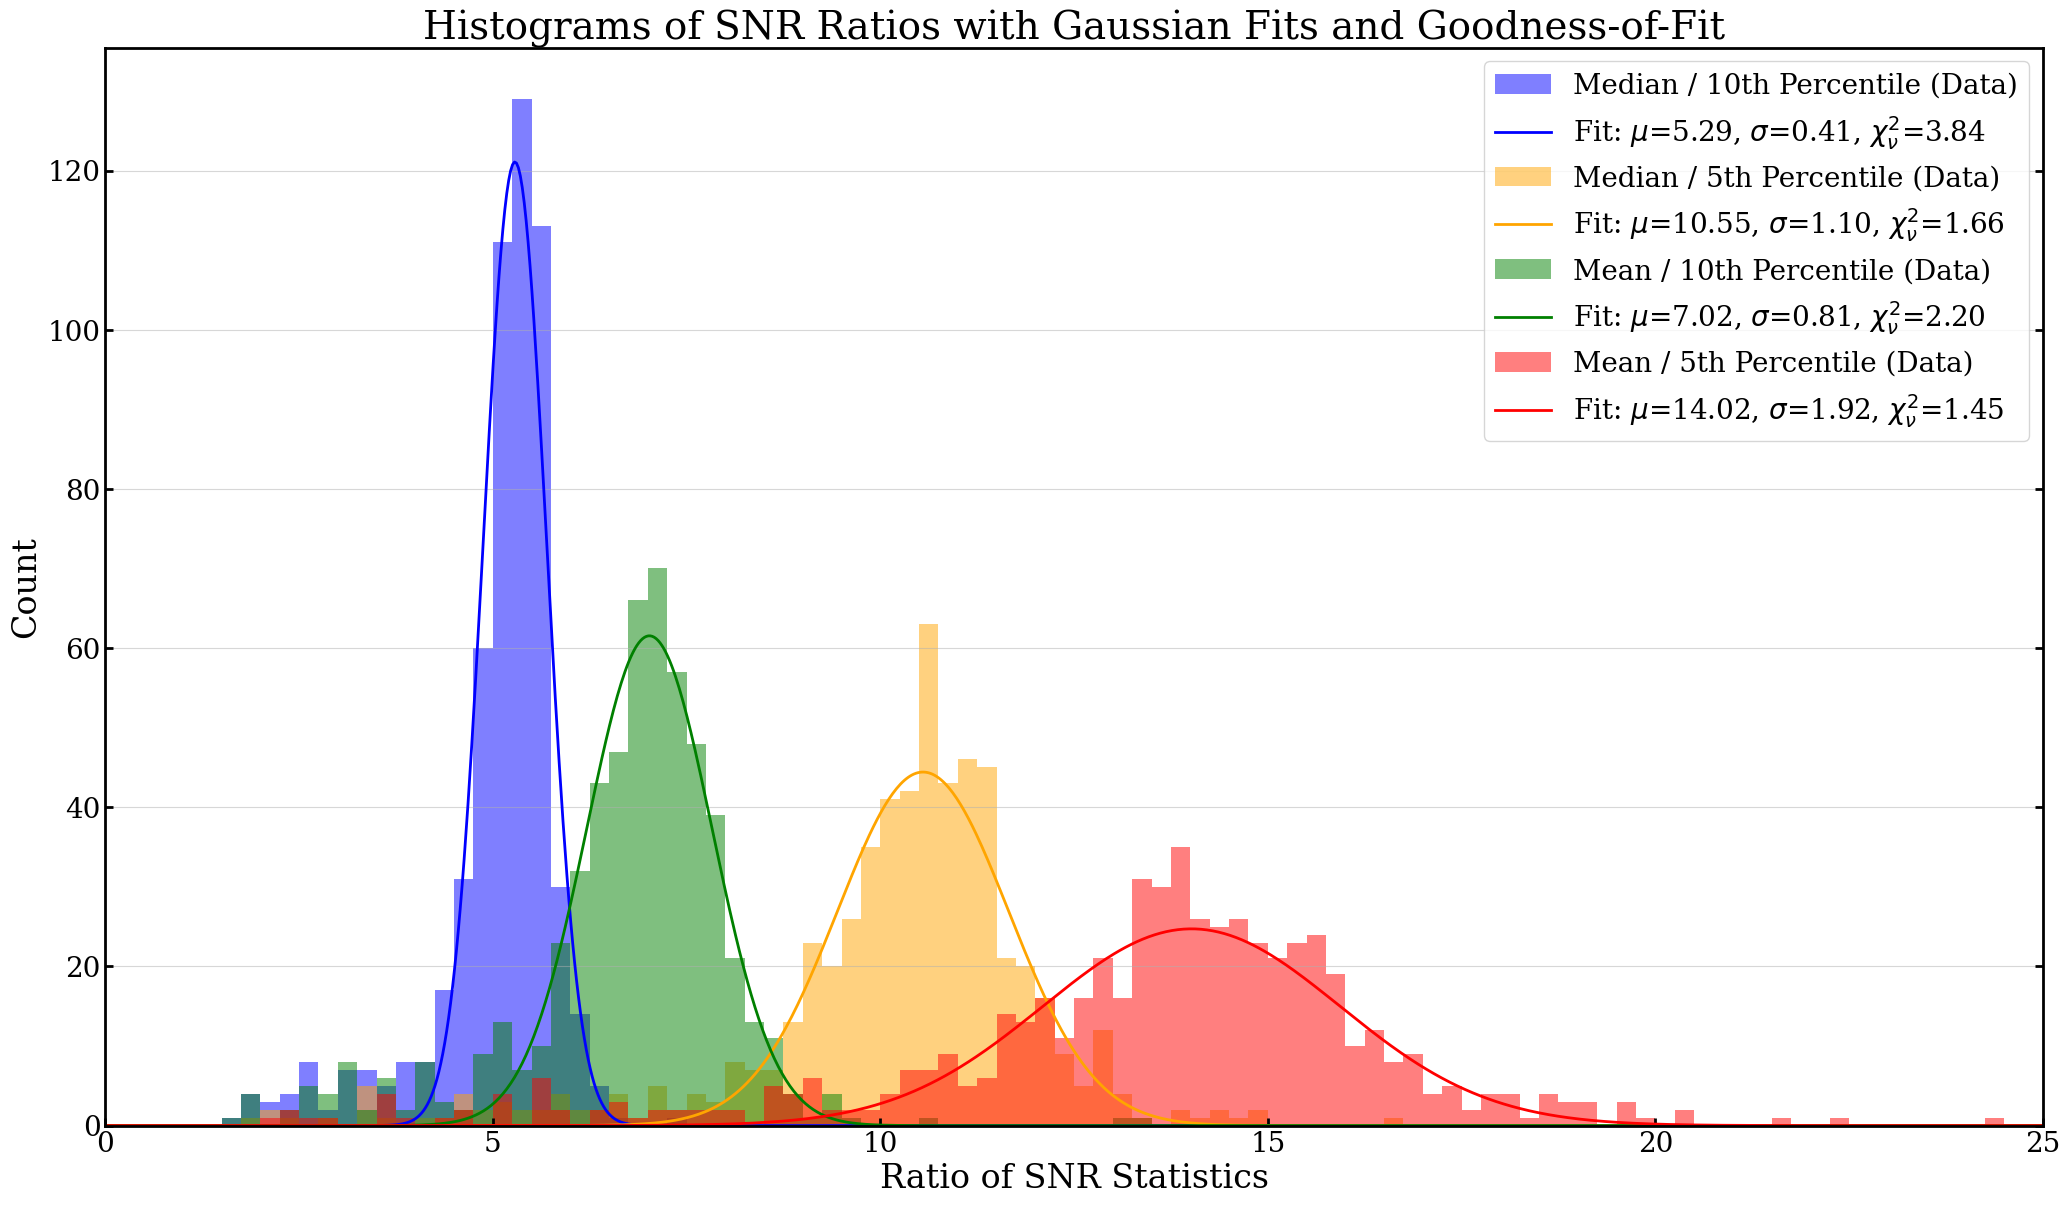

In [218]:

# 1. 定义高斯函数 (没有背景/偏移 offset)
def gaussian(x, A, mu, sigma):
    """A * exp(-(x-mu)^2 / (2*sigma^2))"""
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# 2. 准备要拟合的数据列表
datasets_raw = [
    (median / percentile_10, 'Median / 10th Percentile', 'blue'),
    (median / percentile_5, 'Median / 5th Percentile', 'orange'),
    (mean / percentile_10, 'Mean / 10th Percentile', 'green'),
    (mean / percentile_5, 'Mean / 5th Percentile', 'red')
]

# 3. 设置绘图
fig, ax = plt.subplots(figsize=(25, 14))
n_bins = 100
x_range = (0, 25) # 统一的X轴范围

# 存储拟合结果用于报告 (可选)
fit_results = []

for data_raw, label, color in datasets_raw:
    # ====== 关键修改：筛选掉 NaN 和 Inf ======
    data = data_raw[np.isfinite(data_raw)]

    # 检查数据是否足够进行拟合
    if len(data) < 10:
        print(f"Skipping {label}: Insufficient valid data.")
        continue
    # ==========================================

    # 3a. 计算直方图的 bin 计数和 bin 边缘
    counts, bin_edges = np.histogram(data, bins=n_bins, range=x_range)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 3b. 初始参数猜测 (p0): [Amplitude, Mean, Sigma]
    p0 = [np.max(counts), np.mean(data), np.std(data)]

    # 3c. 进行高斯拟合
    try:
        # 使用 counts 的平方根作为误差，进行加权拟合
        sigma_counts = np.sqrt(counts)
        sigma_counts[sigma_counts == 0] = 1 # 避免除以零

        # 将 count == 0 的 bin 排除在外，避免卡方计算错误
        valid_bins = counts > 0
        bin_centers_fit = bin_centers[valid_bins]
        counts_fit = counts[valid_bins]
        sigma_counts_fit = sigma_counts[valid_bins]

        if len(counts_fit) <= len(p0): # 检查自由度是否为正
             print(f"Skipping {label}: Not enough data points for a meaningful fit after filtering.")
             ax.hist(data, bins=n_bins, alpha=0.5, label=label + " (Fit Skipped)", range=x_range, color=color)
             continue

        popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit,
                               p0=p0, sigma=sigma_counts_fit, absolute_sigma=True) # absolute_sigma=True 很重要
        A_fit, mu_fit, sigma_fit = popt

        # 3d. ## 新增：计算约化卡方 (Reduced Chi-squared)
        #     计算模型在每个点的值
        y_model_fit = gaussian(bin_centers_fit, A_fit, mu_fit, sigma_fit)
        #     计算卡方值
        chi_squared = np.sum(((counts_fit - y_model_fit) / sigma_counts_fit)**2)
        #     计算自由度 (dof)
        dof = len(counts_fit) - len(popt)
        #     计算约化卡方
        reduced_chi_squared = chi_squared / dof if dof > 0 else np.inf

        # 3e. 绘制直方图
        ax.hist(data, bins=n_bins, alpha=0.5, label=f'{label} (Data)', range=x_range, color=color)

        # 3f. 叠加拟合的高斯曲线 (使用更精细的 X 值)
        x_fit = np.linspace(x_range[0], x_range[1], 1000)
        y_fit = gaussian(x_fit, A_fit, mu_fit, sigma_fit)

        # ## 修改：在图例中加入约化卡方的值
        # 使用 LaTeX 语法 `\chi^2_{\nu}` 来美化显示
        fit_label = (f'Fit: $\mu$={mu_fit:.2f}, $\sigma$={sigma_fit:.2f}, '
                     f'$\\chi^2_\\nu$={reduced_chi_squared:.2f}')
        ax.plot(x_fit, y_fit, color=color, linestyle='-', linewidth=2, label=fit_label)

    except Exception as e:
        print(f"Error: Could not fit Gaussian to {label}. Reason: {e}")
        ax.hist(data, bins=n_bins, alpha=0.5, label=label + " (Fit Failed)", range=x_range, color=color)


# 4. 添加图表美化
ax.set_xlabel('Ratio of SNR Statistics', fontsize=24)
ax.set_ylabel('Count', fontsize=24)
ax.set_title('Histograms of SNR Ratios with Gaussian Fits and Goodness-of-Fit', fontsize=28)
ax.legend(fontsize=20) # 调整字体大小以容纳更多信息
ax.grid(axis='y', alpha=0.5)
ax.set_ylim(bottom=0) # 确保Y轴从0开始
ax.set_xlim(left=0,right=25)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('bottom')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')


plt.savefig('./spectrum_snr_ratio_statistics_with_chi_squared.pdf')

Text(0.5, 1.0, 'Selection of High-Quality Spectra')

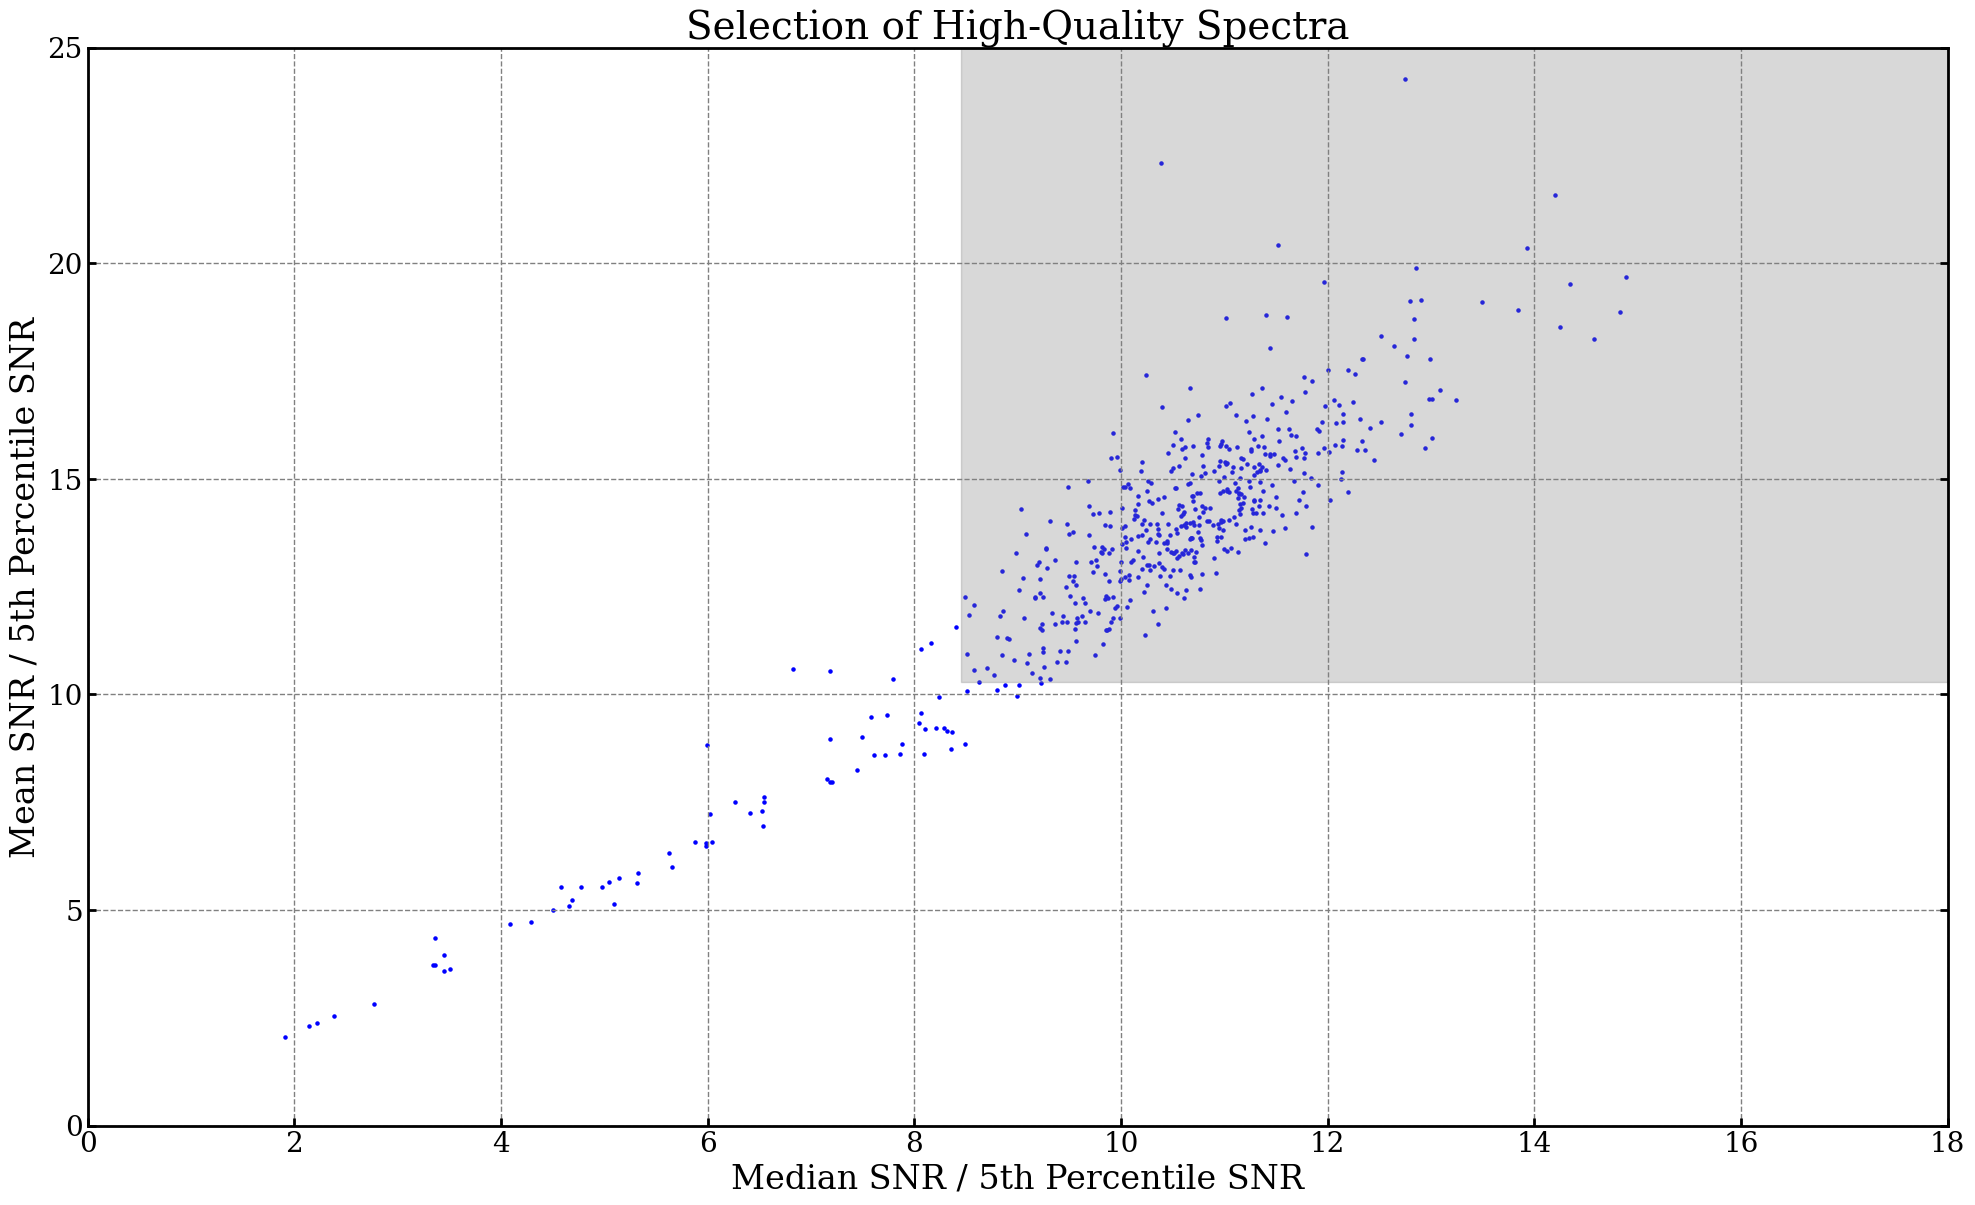

In [217]:
fig, ax=plt.subplots(figsize=(24,14))
ax.scatter(median/percentile_5, mean/percentile_5,s=5,c='blue',alpha=1)
ax.set_xlim(0,18)
ax.set_ylim(0,25)
ax.set_xlabel('Median SNR / 5th Percentile SNR', fontsize=24)
ax.set_ylabel('Mean SNR / 5th Percentile SNR', fontsize=24)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('bottom')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')

ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=1)

ax.fill_between((10.57-2*1.06,18), (13.77-2*1.74),(25), color='gray', alpha=0.3)
ax.set_title('Selection of High-Quality Spectra', fontsize=28)


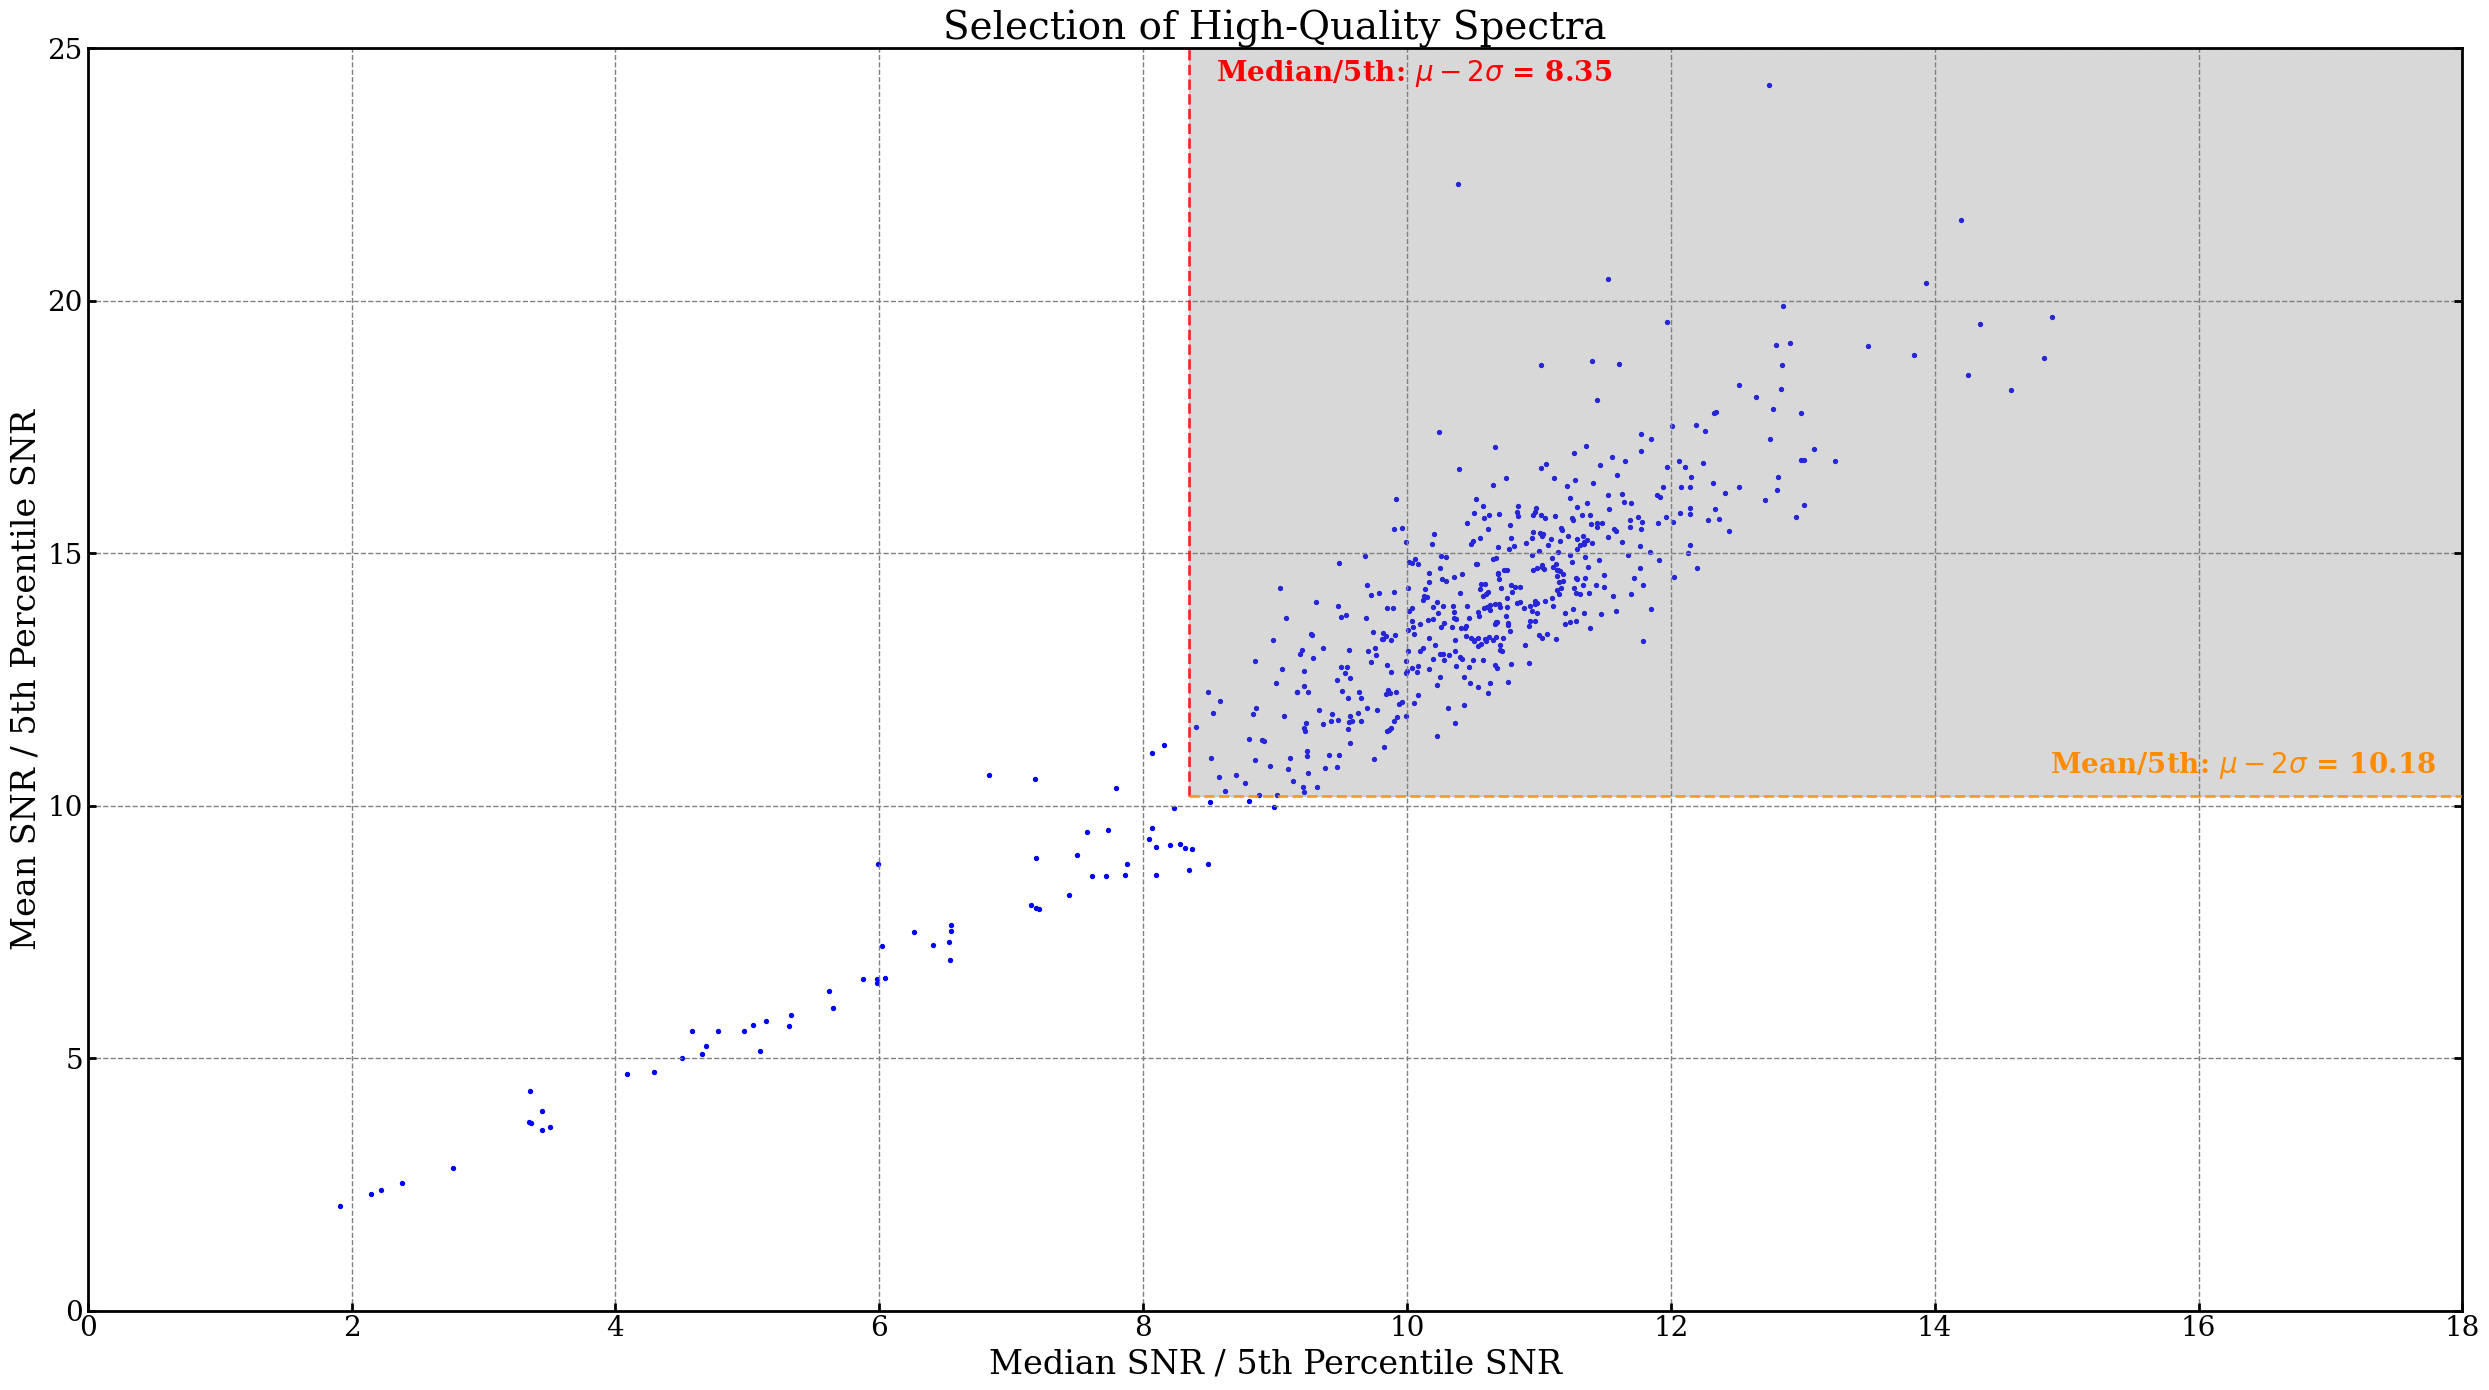

In [219]:
mu_x = 10.55
sigma_x = 1.10
mu_y = 14.02
sigma_y = 1.92

x_boundary = mu_x - 2 * sigma_x  # 10.57 - 2*1.06
y_boundary = mu_y - 2 * sigma_y  # 13.77 - 2*1.74

fig, ax=plt.subplots(figsize=(25,14))
ax.scatter(median/percentile_5, mean/percentile_5,s=8,c='blue',alpha=1)
ax.set_xlim(0,18)
ax.set_ylim(0,25)
ax.set_xlabel('Median SNR / 5th Percentile SNR', fontsize=24)
ax.set_ylabel('Mean SNR / 5th Percentile SNR', fontsize=24)

# 绘制灰色填充区域
# 填充区域的边界是：X 从 x_boundary 到 18，Y 从 y_boundary 到 25
ax.fill_between((x_boundary, 18), (y_boundary), (25), color='gray', alpha=0.3)


# === 新增代码：绘制并标注 X 轴限制线 (右侧) ===

# 1. 绘制垂直边界线
ax.plot((x_boundary, x_boundary), (y_boundary, 25), color='red', linestyle='--', linewidth=2, alpha=0.8, zorder=5)

# 2. 在右侧顶部附近添加标注文本
# X 坐标设置在 x_boundary 附近，Y 坐标设置在图表顶部附近 (使用 ax.transAxes)
text_x_pos = x_boundary + 0.2  # 稍微偏右一点
text_y_pos = 24.8  # 靠近图的顶部
ax.text(text_x_pos, text_y_pos,
        f'Median/5th: $\mu - 2\\sigma$ = {x_boundary:.2f}',
        transform=ax.transData, # 使用数据坐标系
        color='red',
        fontsize=20,
        fontweight='bold',
        ha='left',
        va='top')

# === 新增代码：绘制并标注 Y 轴限制线 (上侧) ===

# 1. 绘制水平边界线
ax.plot((x_boundary, 18), (y_boundary, y_boundary), color='darkorange', linestyle='--', linewidth=2, alpha=0.8, zorder=5)

# 2. 在上侧右端附近添加标注文本
# Y 坐标设置在 y_boundary 附近，X 坐标设置在图表的右侧附近
text_x_pos_h = 17.8 # 靠近图的右侧 (使用 ax.transAxes)
text_y_pos_h = y_boundary + 0.3 # 稍微偏上一点
ax.text(text_x_pos_h, text_y_pos_h,
        f'Mean/5th: $\mu - 2\\sigma$ = {y_boundary:.2f}',
        transform=ax.transData, # 使用数据坐标系
        color='darkorange',
        fontsize=20,
        fontweight='bold',
        ha='right',
        va='bottom')


# 保持原有的轴样式设置
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('bottom')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')

ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=1)
ax.set_title('Selection of High-Quality Spectra', fontsize=28)

plt.tight_layout()
plt.savefig('./high_quality_spectra_selection.pdf')

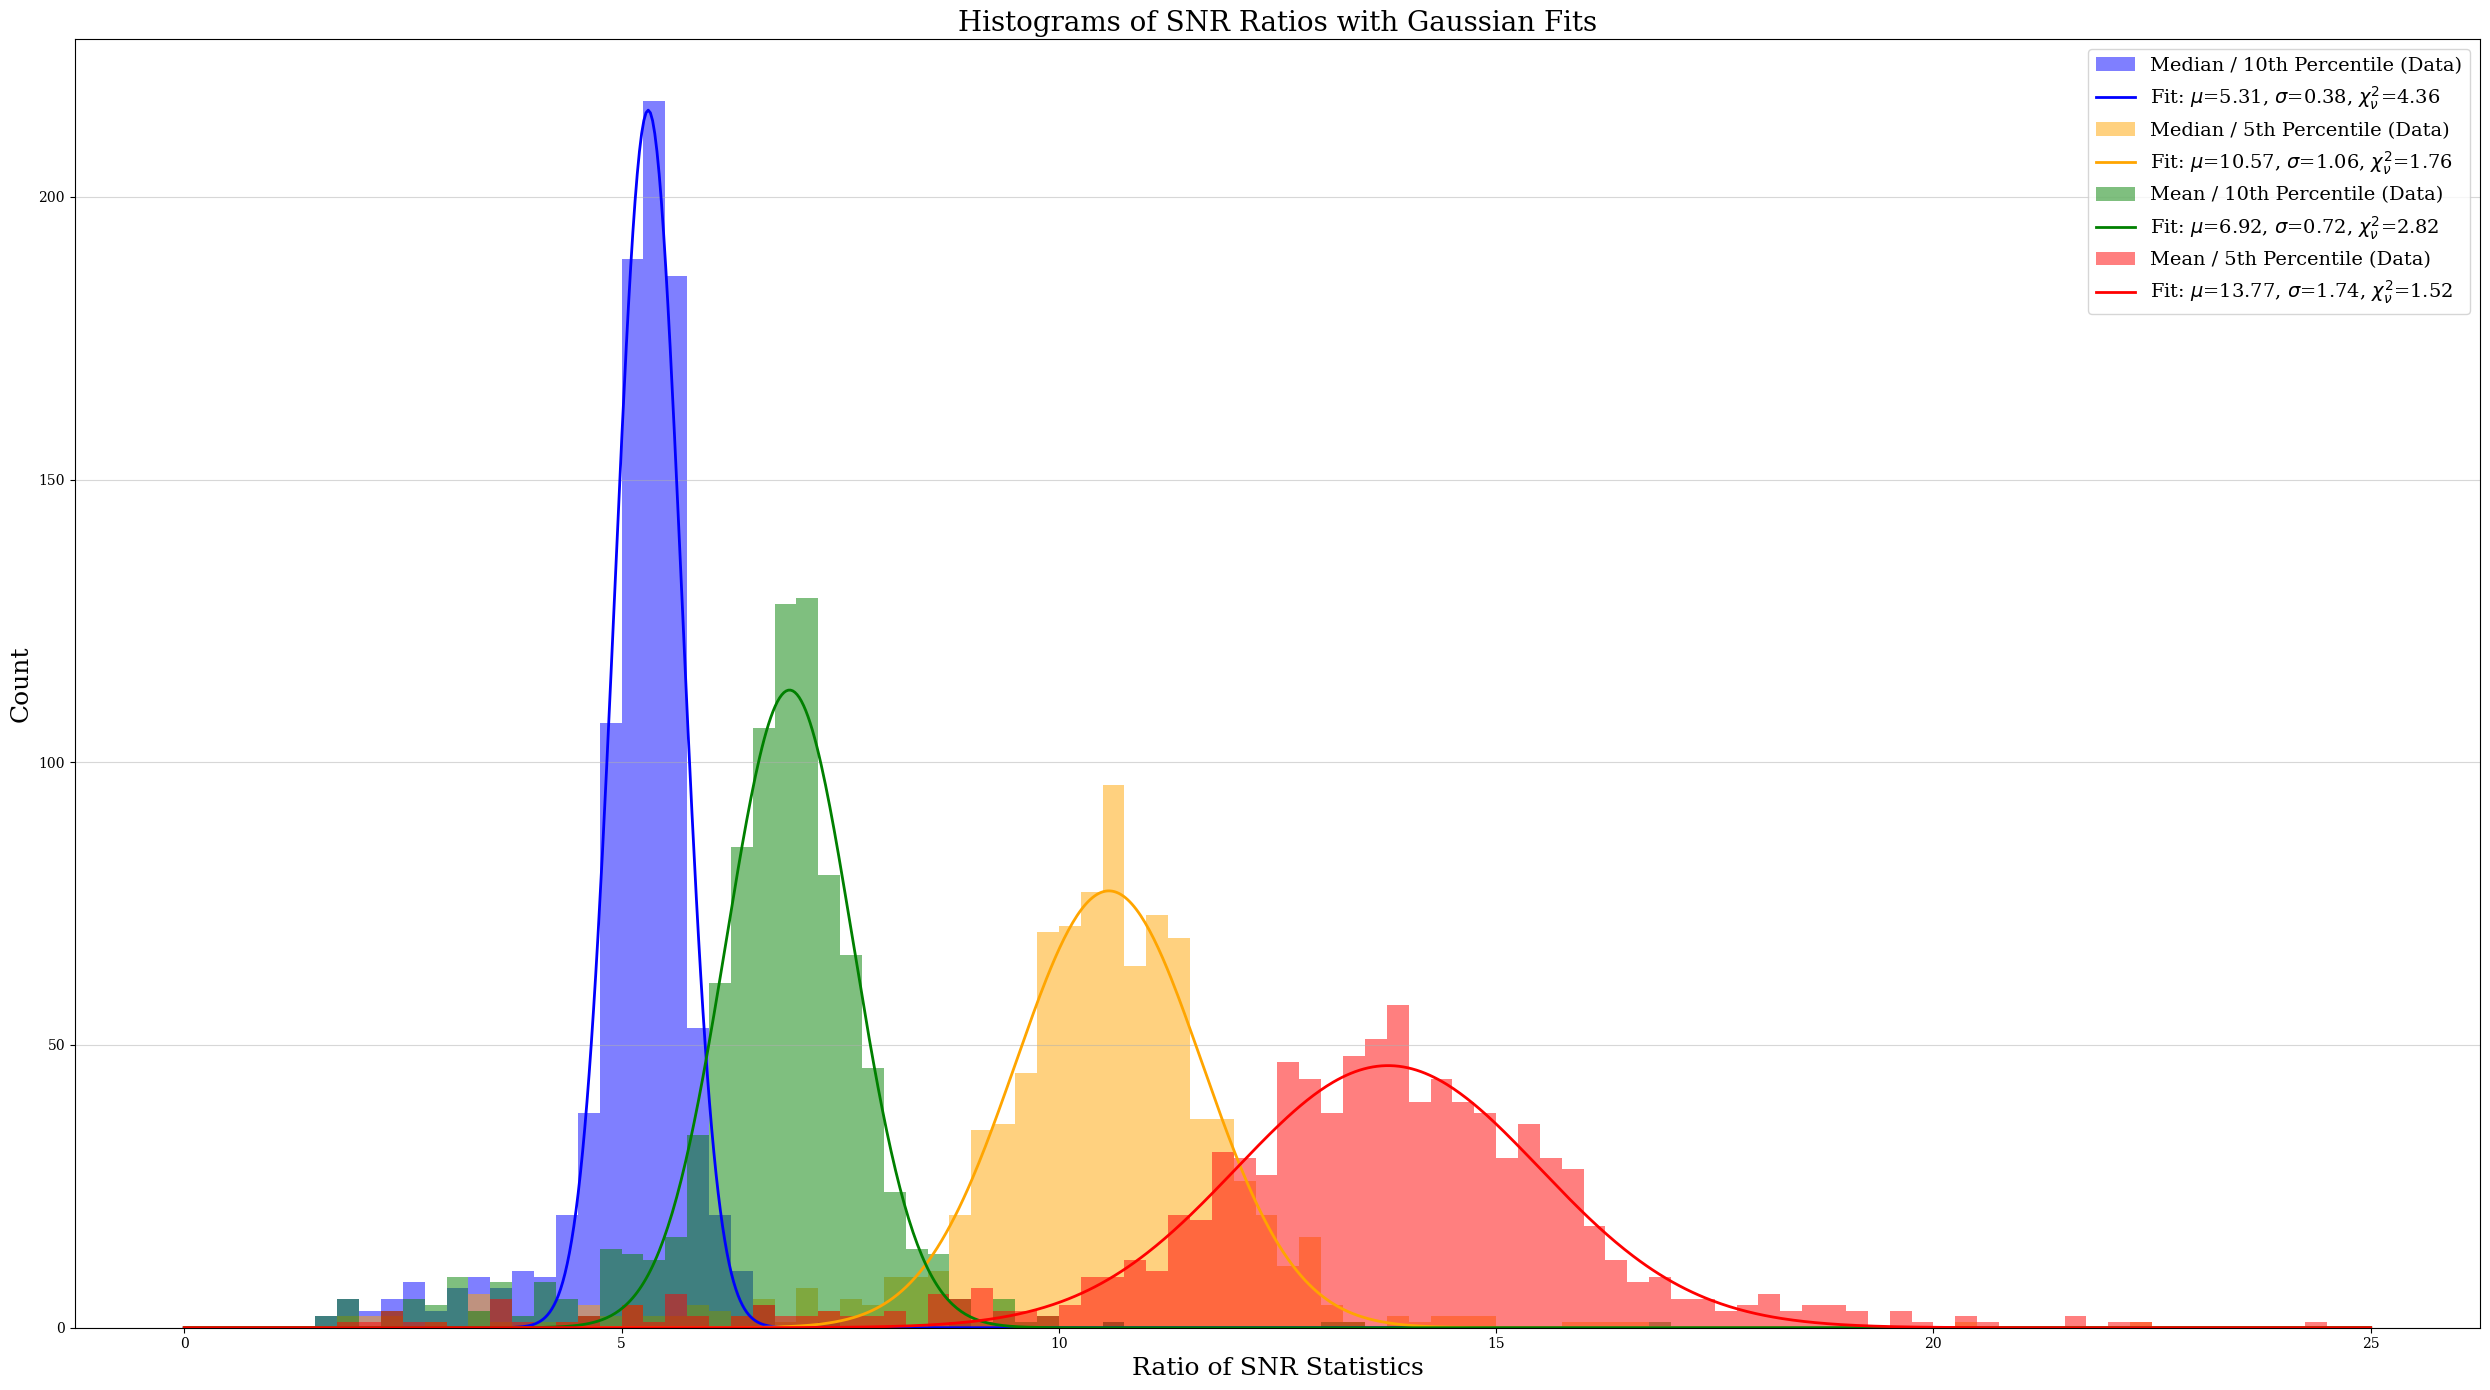


--- 存储的筛选后数据数组的长度 ---
Median / 5th Percentile: 915 valid points.
Mean / 5th Percentile: 915 valid points.

--- 存储的拟合结果 ---
{
    "Median / 5th Percentile": {
        "mu": 10.57245797068476,
        "sigma": 1.0647511431121506,
        "chi_sq_red": 1.7598761745297193
    },
    "Mean / 5th Percentile": {
        "mu": 13.765116504151994,
        "sigma": 1.739553610430576,
        "chi_sq_red": 1.524865643483911
    }
}


In [174]:
def gaussian(x, A, mu, sigma):
    """A * exp(-(x-mu)^2 / (2*sigma^2))"""
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# 2. 准备要拟合的数据列表
datasets_raw = [
    (median / percentile_10, 'Median / 10th Percentile', 'blue'),
    (median / percentile_5, 'Median / 5th Percentile', 'orange'),
    (mean / percentile_10, 'Mean / 10th Percentile', 'green'),
    (mean / percentile_5, 'Mean / 5th Percentile', 'red')
]

# === 新增：存储筛选后的数据和拟合结果的字典 ===
selected_data = {}
selected_fits = {}
# ===============================================

# 3. 设置绘图
fig, ax = plt.subplots(figsize=(25, 14))
n_bins = 100
x_range = (0, 25) # 统一的X轴范围

for data_raw, label, color in datasets_raw:
    # ====== 关键修改：筛选掉 NaN 和 Inf ======
    data = data_raw[np.isfinite(data_raw)]

    # 检查数据是否足够进行拟合
    if len(data) < 10:
        print(f"Skipping {label}: Insufficient valid data.")
        continue

    # === 新增：存储 Median/5th 和 Mean/5th 的数据 ===
    if '5th Percentile' in label:
        selected_data[label] = data.copy() # 存储筛选后的数据数组
    # =================================================

    # 3a. 计算直方图的 bin 计数和 bin 边缘
    counts, bin_edges = np.histogram(data, bins=n_bins, range=x_range)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 3b. 初始参数猜测 (p0): [Amplitude, Mean, Sigma]
    p0 = [np.max(counts), np.mean(data), np.std(data)]

    # 3c. 进行高斯拟合
    try:
        sigma_counts = np.sqrt(counts)
        sigma_counts[sigma_counts == 0] = 1

        valid_bins = counts > 0
        bin_centers_fit = bin_centers[valid_bins]
        counts_fit = counts[valid_bins]
        sigma_counts_fit = sigma_counts[valid_bins]

        if len(counts_fit) <= len(p0):
             print(f"Skipping {label}: Not enough data points for a meaningful fit after filtering.")
             ax.hist(data, bins=n_bins, alpha=0.5, label=label + " (Fit Skipped)", range=x_range, color=color)
             continue

        popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit,
                               p0=p0, sigma=sigma_counts_fit, absolute_sigma=True)
        A_fit, mu_fit, sigma_fit = popt

        # 3d. 计算约化卡方 (Reduced Chi-squared)
        y_model_fit = gaussian(bin_centers_fit, A_fit, mu_fit, sigma_fit)
        chi_squared = np.sum(((counts_fit - y_model_fit) / sigma_counts_fit)**2)
        dof = len(counts_fit) - len(popt)
        reduced_chi_squared = chi_squared / dof if dof > 0 else np.inf

        # === 新增：存储 Median/5th 和 Mean/5th 的拟合结果 ===
        if '5th Percentile' in label:
             selected_fits[label] = {
                 'mu': mu_fit,
                 'sigma': sigma_fit,
                 'chi_sq_red': reduced_chi_squared
             }
        # =====================================================

        # 3e. 绘制直方图
        ax.hist(data, bins=n_bins, alpha=0.5, label=f'{label} (Data)', range=x_range, color=color)

        # 3f. 叠加拟合的高斯曲线
        x_fit = np.linspace(x_range[0], x_range[1], 1000)
        y_fit = gaussian(x_fit, A_fit, mu_fit, sigma_fit)

        fit_label = (f'Fit: $\mu$={mu_fit:.2f}, $\sigma$={sigma_fit:.2f}, '
                     f'$\\chi^2_\\nu$={reduced_chi_squared:.2f}')
        ax.plot(x_fit, y_fit, color=color, linestyle='-', linewidth=2, label=fit_label)

    except Exception as e:
        print(f"Error: Could not fit Gaussian to {label}. Reason: {e}")
        ax.hist(data, bins=n_bins, alpha=0.5, label=label + " (Fit Failed)", range=x_range, color=color)


# 4. 图表美化 (略)
ax.set_xlabel('Ratio of SNR Statistics', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_title('Histograms of SNR Ratios with Gaussian Fits', fontsize=20)
ax.legend(fontsize=14)
ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

# === 打印和展示存储的结果 ===
print("\n--- 存储的筛选后数据数组的长度 ---")
for label, data_arr in selected_data.items():
    print(f"{label}: {len(data_arr)} valid points.")

print("\n--- 存储的拟合结果 ---")
import json
print(json.dumps(selected_fits, indent=4))